# Bank Personal Loan Prediction

## Project Overview
This project aims to predict whether a bank customer will accept a personal loan offer based on their demographic and financial attributes. The dataset contains information about **5,000 customers** including their age, income, education, credit card spending, mortgage, and more.

### Objectives
- Perform **Exploratory Data Analysis (EDA)** to understand the data distribution and relationships between features.
- Build and evaluate classification models: **Logistic Regression**, **K-Nearest Neighbors (KNN)**, and **Complement Naive Bayes**.
- Compare model performance using **F1 Score** and **Accuracy** metrics.

> **Note:** As per the client's requirements, only **Logistic Regression**, **K-Nearest Neighbors (KNN)**, and **Naive Bayes** are to be used as the classification models for this project.

### Dataset
- **Source:** Bank Personal Loan Modelling dataset
- **Target Variable:** `Personal Loan` (1 = Accepted, 0 = Not Accepted)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report,roc_curve, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import GridSearchCV,train_test_split,cross_val_score, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import warnings

In [2]:
warnings.filterwarnings('ignore')

## 2. Load & Explore Data

### Attribute Information

| # | Feature | Description |
|---|---------|-------------|
| 1 | **ID** | Customer ID |
| 2 | **Age** | Customer's age in completed years |
| 3 | **Experience** | Years of professional experience |
| 4 | **Income** | Annual income of the customer ($000) |
| 5 | **ZIP Code** | Home address ZIP code |
| 6 | **Family** | Family size of the customer |
| 7 | **CCAvg** | Average spending on credit cards per month ($000) |
| 8 | **Education** | Education Level — 1: Undergrad, 2: Graduate, 3: Advanced/Professional |
| 9 | **Mortgage** | Value of house mortgage if any ($000) |
| 10 | **Personal Loan** | Did this customer accept the personal loan offered in the last campaign? (Target Variable) |
| 11 | **Securities Account** | Does the customer have a securities account with the bank? |
| 12 | **CD Account** | Does the customer have a certificate of deposit (CD) account with the bank? |
| 13 | **Online** | Does the customer use internet banking facilities? |
| 14 | **Credit Card** | Does the customer use a credit card issued by the bank? |

In [3]:
df = pd.read_csv('src/Bank_Personal_Loan_Modelling.csv')
df


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [4]:
print(df.info())
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB
None


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,0/30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,NaN,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,NaN,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,NaN,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,NaN,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000


### Custom Data Summary
A custom function to get a quick overview of each column: count, unique values, missing values, and duplicates.

In [5]:
def describe(df):

    variable = []
    unique = []
    count = []
    missing_values = []
    duplicate = []
    

    for col in df.columns:
        variable.append(col)
        count.append(df[col].count())
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())
        duplicate.append(df[col].duplicated().sum())

    return(pd.DataFrame({
        'variables' : variable,
        'count' : count,
        'unique' : unique,
        'missing_values': missing_values,
        'duplicate': duplicate
    }
    ))

describe(df)

,variables,count,unique,missing_values,duplicate
0,ID,5000,5000,0,0
1,Age,5000,45,0,4955
2,Experience,5000,47,0,4953
3,Income,5000,162,0,4838
4,ZIP Code,5000,467,0,4533
5,Family,5000,4,0,4996
6,CCAvg,5000,108,0,4892
7,Education,5000,3,0,4997
8,Mortgage,5000,347,0,4653
9,Personal Loan,5000,2,0,4998


The custom summary confirms that there are **no missing values** in any column, so no imputation is needed.

## 3. Data Cleaning & Preprocessing

Before modeling, we need to clean and prepare the data:
- **Drop** the `ID` column (not useful for prediction).
- **Fix** the `CCAvg` column: replace `/` with `.` and convert to float.
- **Fix** negative `Experience` values by taking absolute values.

In [6]:
df = df.drop('ID',axis=1)

df['CCAvg'] = df['CCAvg'].str.replace('/','.').astype(float)

print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB
None


### Fix Negative Experience Values

Some `Experience` values are negative, which is not physically meaningful. We take the absolute value to correct them.

> **Note:** This fix was applied as specified by the client's requirements.

In [7]:
df['Experience'] = abs(df['Experience'])
df['Experience'].min()

np.int64(0)

## 4. Exploratory Data Analysis (EDA)

### 4.1 Correlation Analysis

In [8]:
df.corr()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.993991,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,0.993991,1.000000,-0.046876,-0.028936,-0.051851,-0.049738,0.013919,-0.011097,-0.008304,-0.000989,0.009735,0.014051,0.008851
Income,-0.055269,-0.046876,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,-0.029216,-0.028936,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.046418,-0.051851,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.052012,-0.049738,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.041334,0.013919,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.012539,-0.011097,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.007726,-0.008304,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802
Securities Account,-0.000436,-0.000989,-0.002616,0.004704,0.019994,0.015086,-0.010812,-0.005411,0.021954,1.000000,0.317034,0.012627,-0.015028


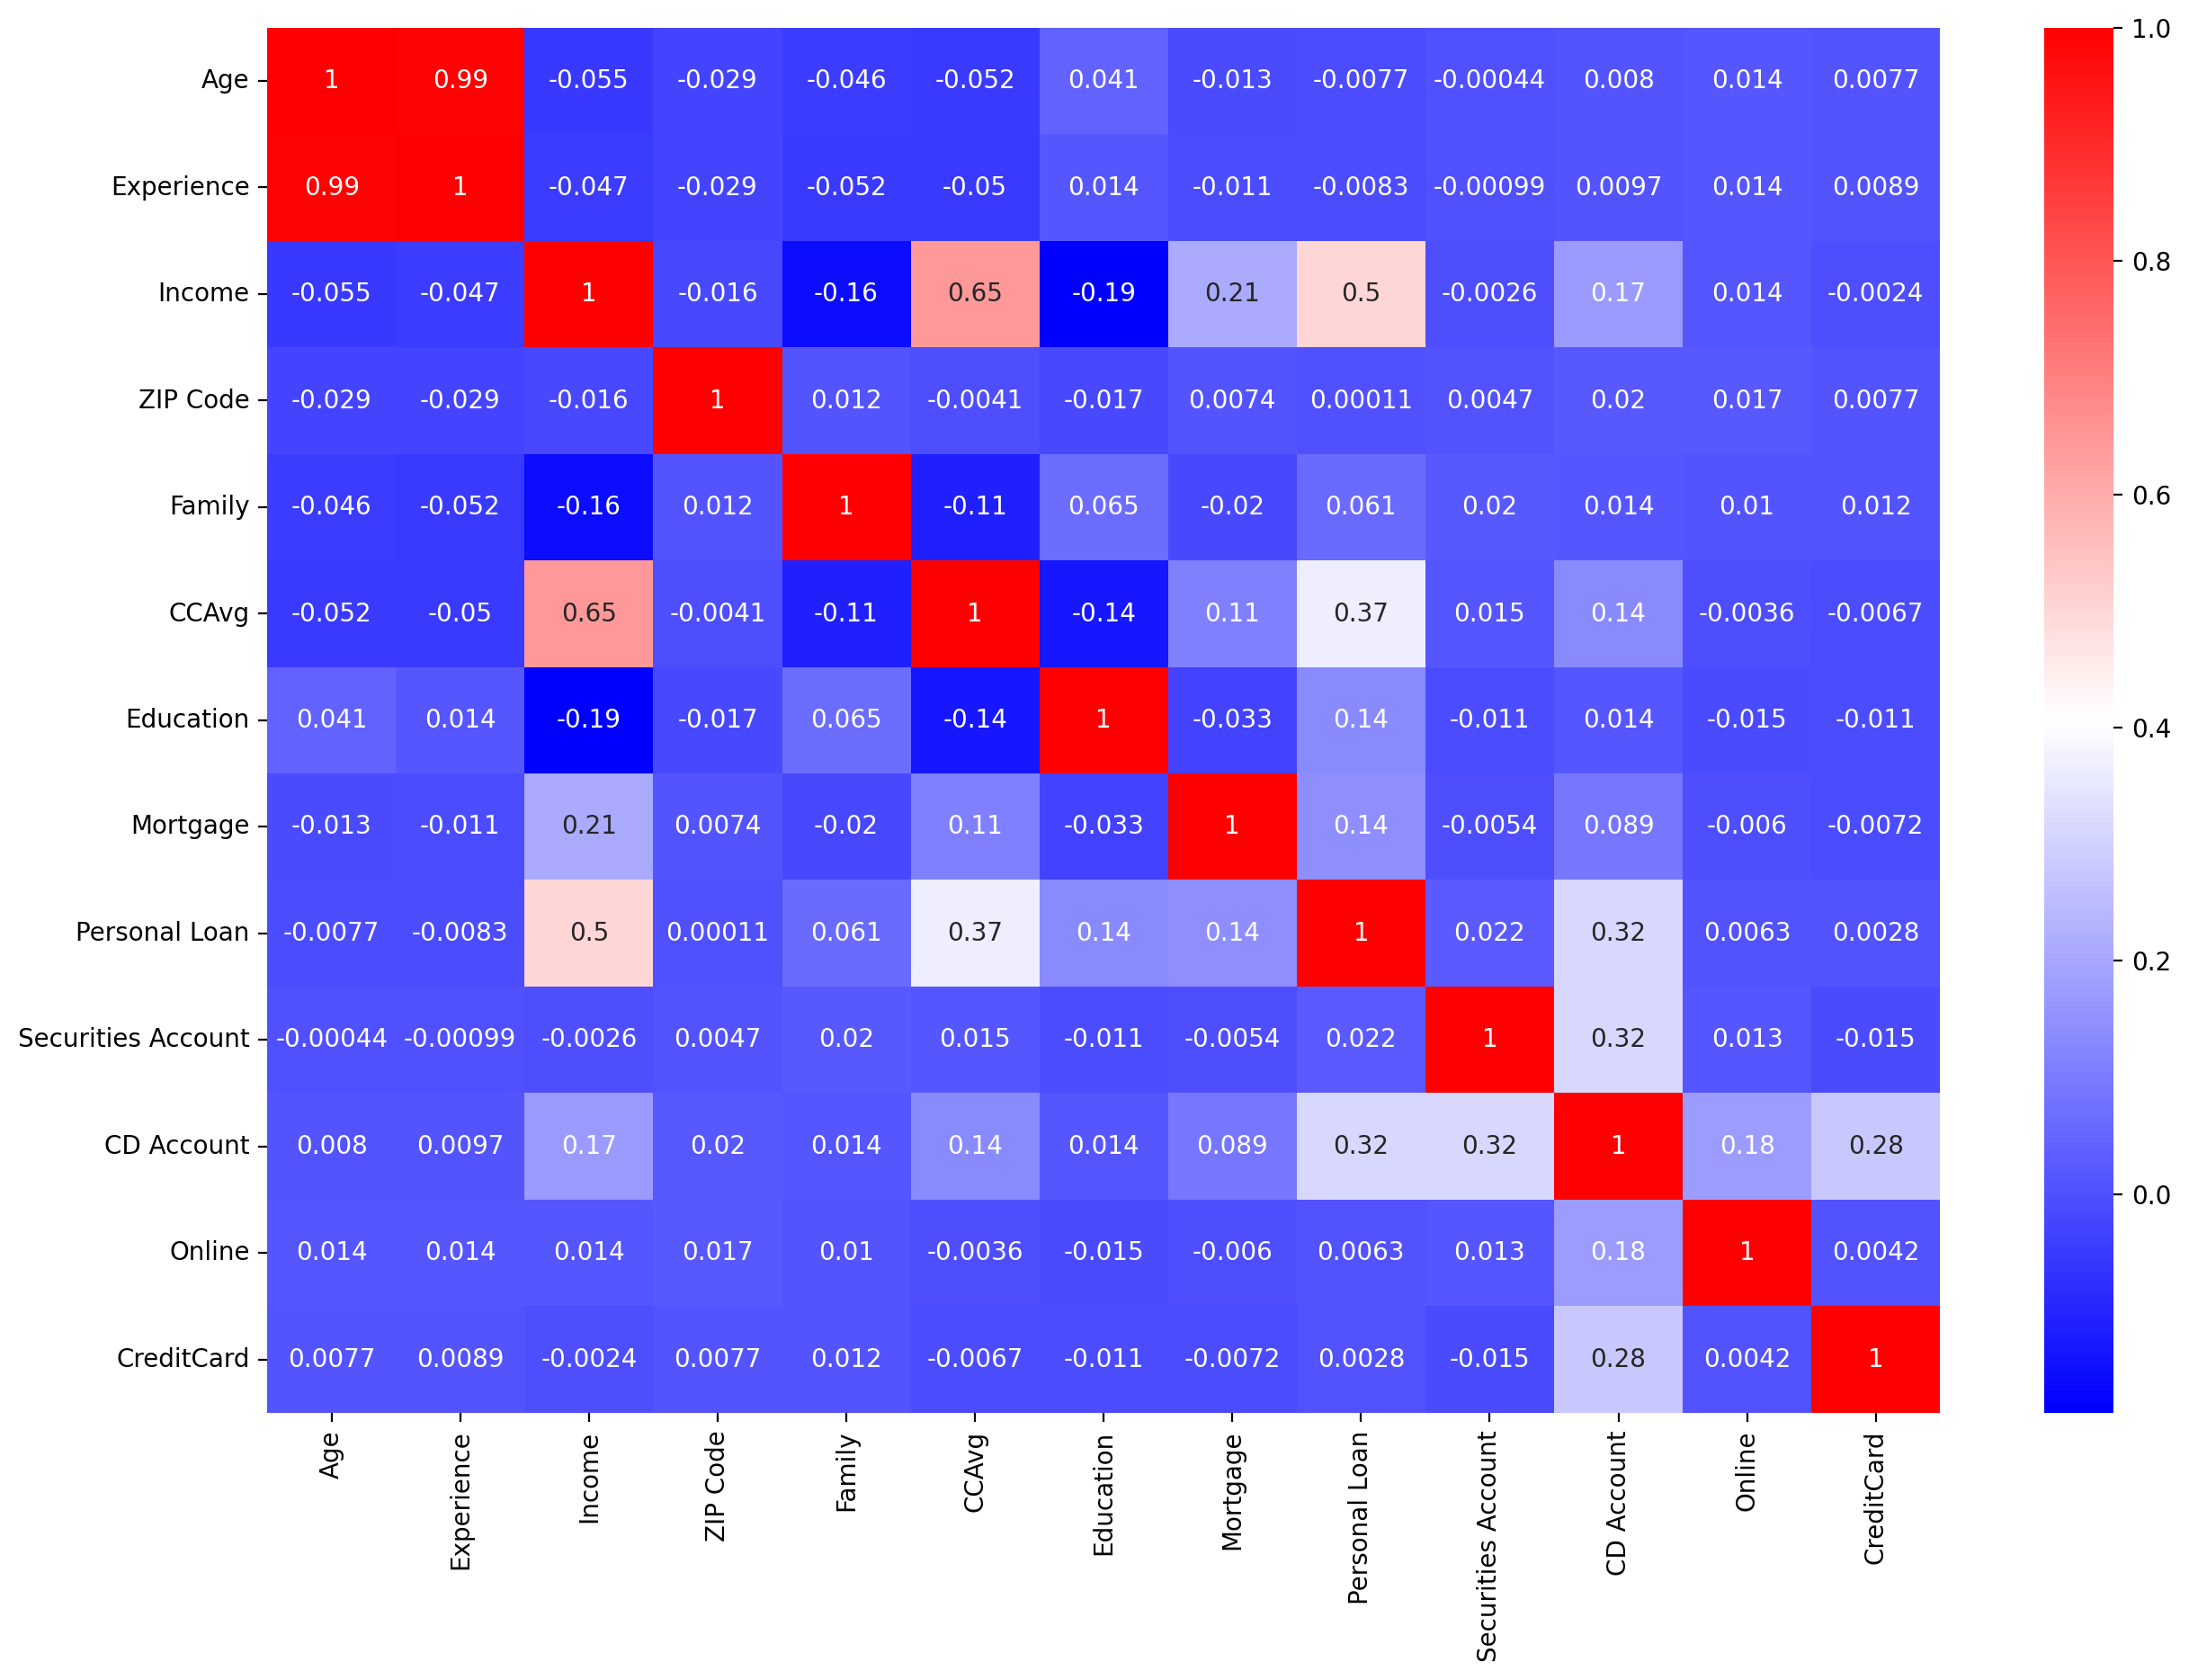

In [9]:
fig,ax = plt.subplots(figsize=(15,10),dpi=200)
sns.heatmap(df.corr(),cmap='bwr',cbar=True,annot=True,ax=ax)
plt.show()

**Understanding:**
- **Age & Experience** have a very strong positive correlation (~0.99), which is expected — older customers tend to have more work experience. This multicollinearity is further demonstrated in the scatter plot below (Section 4.2), where a near-perfect linear relationship between the two variables is clearly visible.
- **Income & CCAvg** show a moderate positive correlation (~0.65) — higher-income customers tend to spend more on credit cards.
- **Personal Loan** has notable positive correlations with **Income** (~0.50), **CCAvg** (~0.37), **CD Account** (~0.32), and **Education** (~0.14), suggesting these features are important predictors.
- Most other features show weak correlations with the target variable.

### 4.2 Scatter Plot Analysis

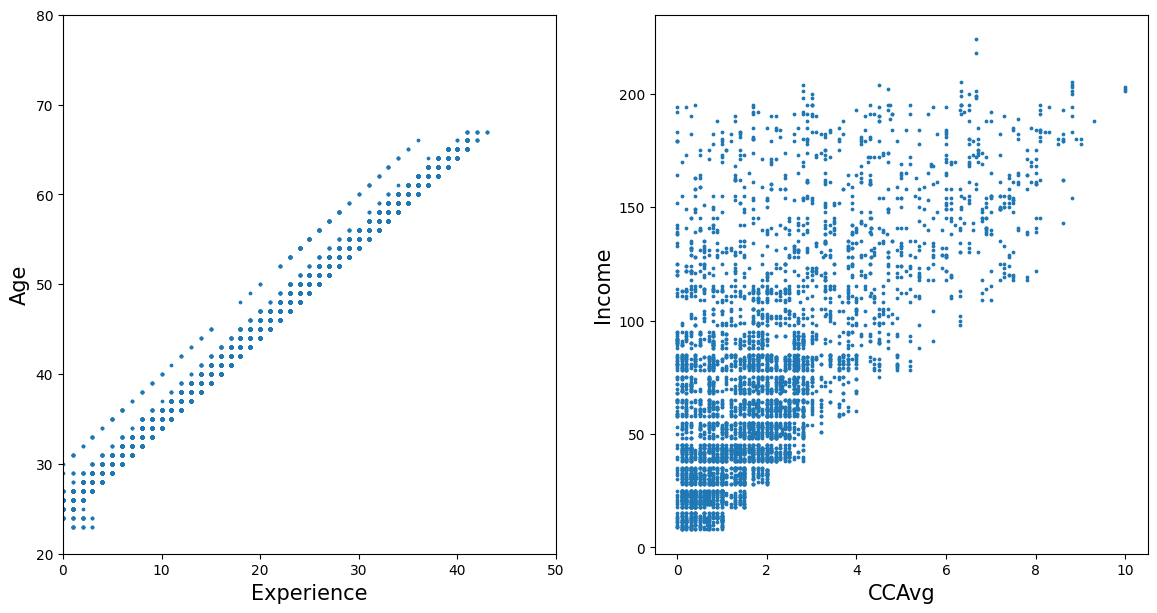

In [10]:
plt.figure(figsize=[14,7])
plt.subplot(1,2,1)
plt.scatter(df['Experience'],df['Age'], s=3)
plt.xlabel('Experience',fontsize=15)
plt.ylabel('Age',fontsize=15)
plt.xlim(0,50)
plt.ylim(20,80)
plt.subplot(1,2,2)
plt.scatter(df['CCAvg'],df['Income'], s=3)
plt.xlabel('CCAvg',fontsize=15)
plt.ylabel('Income',fontsize=15)
plt.show()


- **Experience vs. Age:** There is a near-perfect linear relationship, confirming the extremely high correlation (~0.99). This means one of these features could be dropped without losing much information.
- **CCAvg vs. Income:** A clear positive trend is visible — customers with higher income tend to have higher credit card spending. This relationship supports using both features as predictors for loan acceptance.

### 4.3 Categorical Feature Distribution

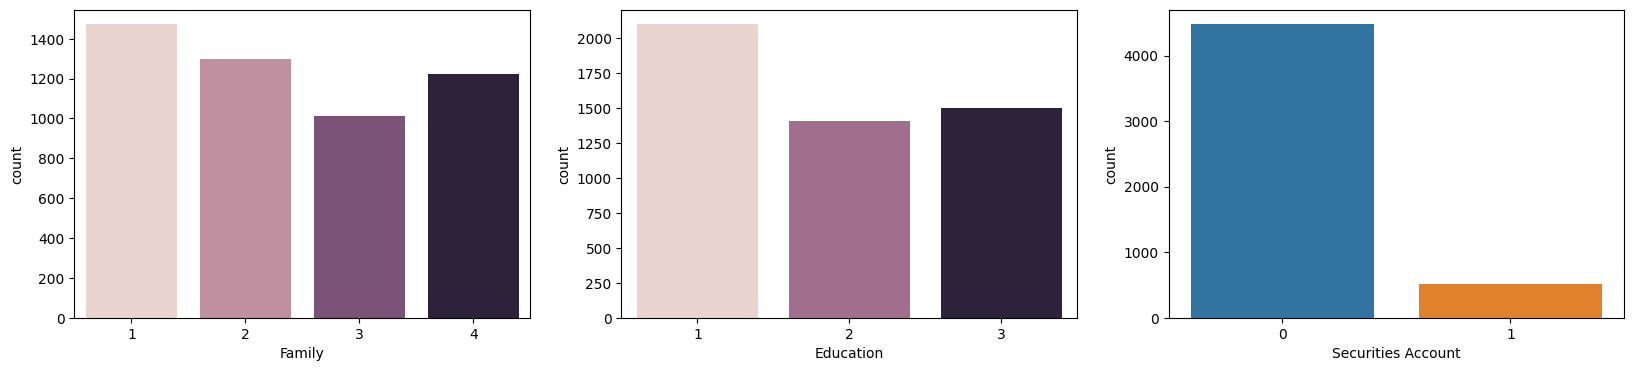

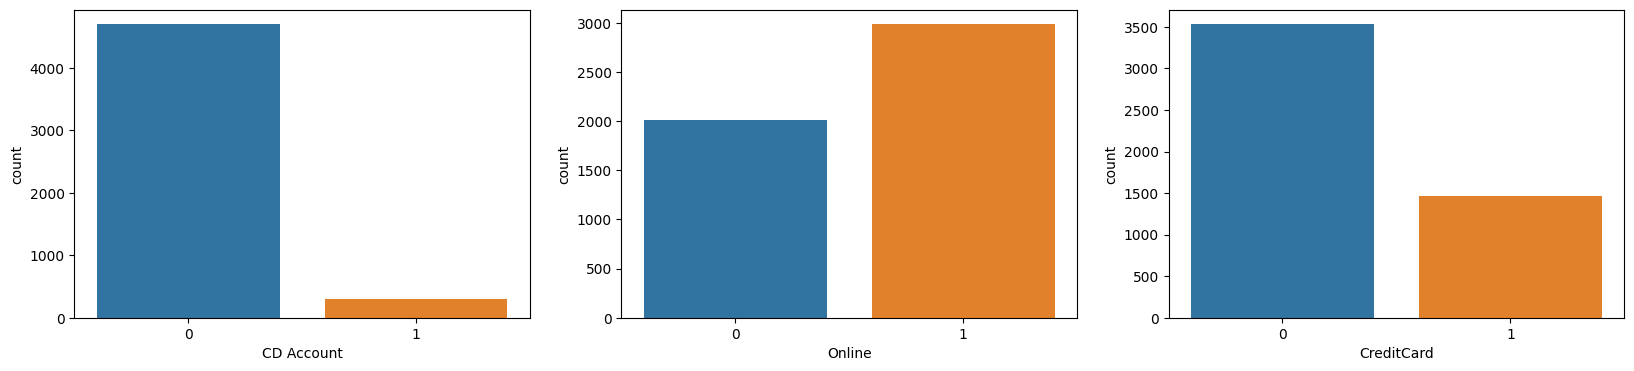

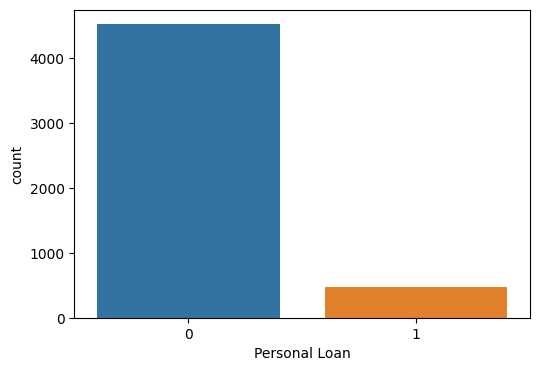

In [11]:
categorical = ['Family','Education','Securities Account','CD Account','Online','CreditCard','Personal Loan']
i = 1
fig = plt.figure(figsize=(20,4))
for cat in categorical:
    plt.subplot(1,3,i)
    sns.countplot(x = cat, data=df, hue= cat, legend= False)
    if i==3:
        plt.show()
        fig = plt.figure(figsize=(20,4))
        i=0
    i += 1

**Understanding:**
- **Family:** Most customers have families of size 1–4, with sizes 1 and 2 being slightly more common.
- **Education:** The three education levels (Undergrad=1, Graduate=2, Advanced/Professional=3) are fairly balanced.
- **Securities Account & CD Account:** The vast majority of customers do **not** hold securities or CD accounts, making these minority classes.
- **Online:** Roughly 60% of customers use online banking.
- **CreditCard:** About 30% of customers hold a credit card with the bank.
- **Personal Loan (Target):** The dataset is **highly imbalanced** — only ~9.6% of customers accepted the loan. This imbalance must be considered during model training and evaluation (e.g., using F1 score instead of accuracy).

### 4.4 Numerical Feature Distribution (Box Plots)

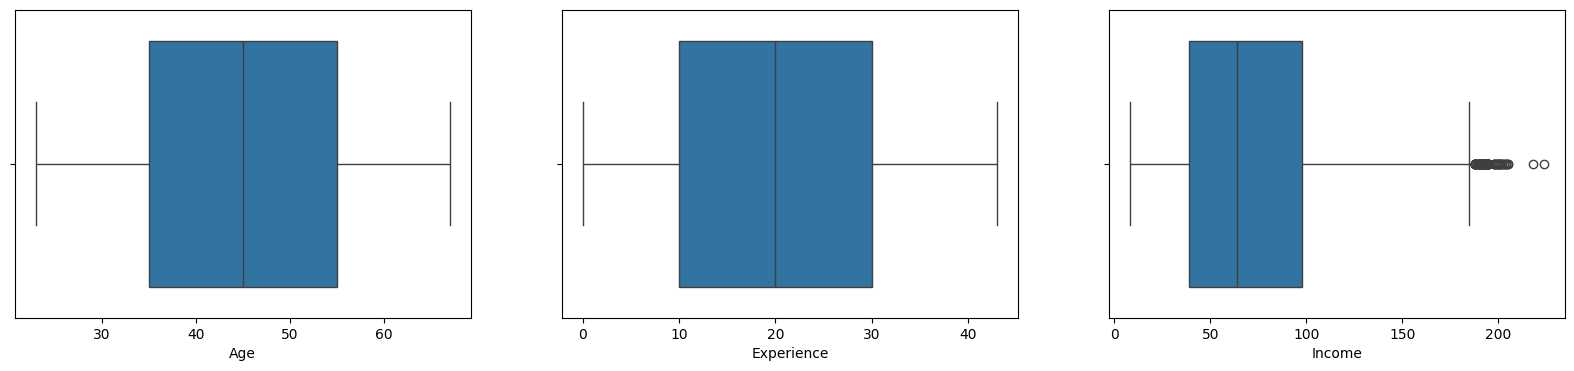

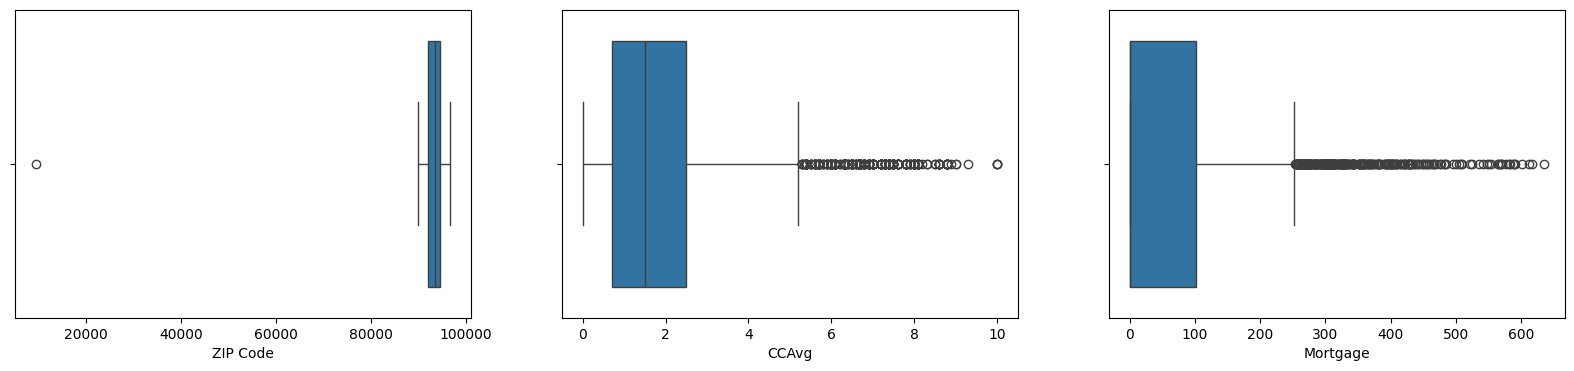

<Figure size 2000x400 with 0 Axes>

In [12]:
numerical = ['Age','Experience','Income','ZIP Code','CCAvg','Mortgage']
i = 1
fig = plt.figure(figsize=(20,4))
for item in numerical:
    plt.subplot(1,3,i)
    sns.boxplot(x = item, data=df)
    if i==3:
        plt.show()
        fig = plt.figure(figsize=(20,4))
        i=0
    i += 1


- **Age & Experience:** Fairly symmetric distributions with no significant outliers.
- **Income:** Right-skewed distribution — most customers earn moderate incomes, with a few high earners.
- **ZIP Code:** One extreme outlier (9307) is clearly visible, far below the typical range. This is likely a data entry error and needs removal.
- **CCAvg:** Right-skewed with several high-spending outliers.
- **Mortgage:** Heavily right-skewed — most customers have zero or low mortgage values, with some extreme values above 400.

### 4.5 ZIP Code Outlier Removal

The box plot revealed a ZIP Code value of **9307**, which is clearly an outlier (valid US ZIP codes are 5 digits starting from ~00501). We remove this entry and verify the cleaned distribution.

In [13]:
df['ZIP Code'].min()

np.int64(9307)

In [14]:
df=df[df['ZIP Code']!=9307]
df.shape

(4999, 13)

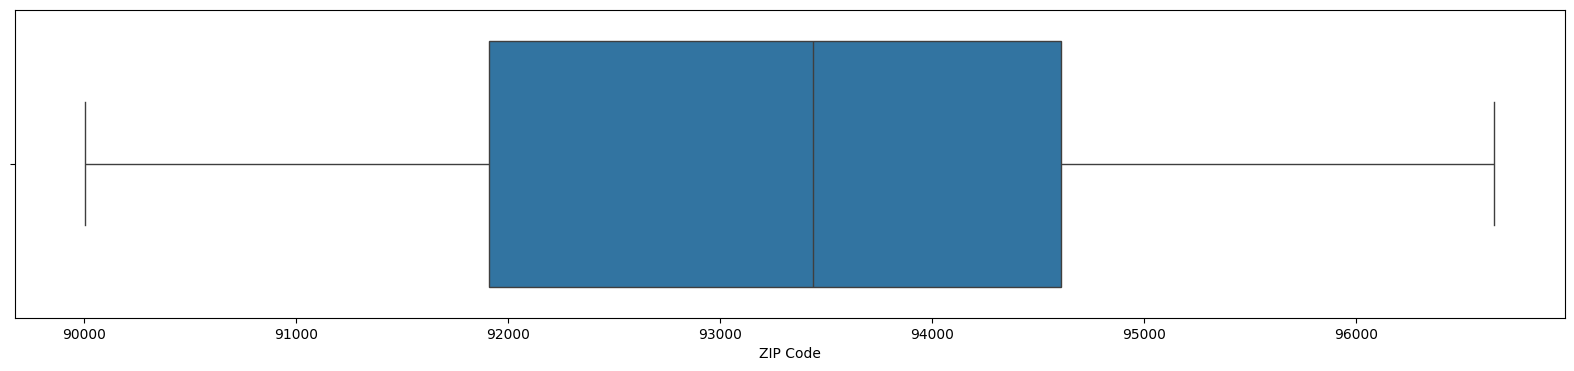

In [15]:
fig = plt.figure(figsize=(20,4))
sns.boxplot(x = 'ZIP Code', data=df)
plt.show()

**Understanding:** After removing the outlier (9307), the ZIP Code distribution looks clean with no remaining extreme values.

### 4.6 Income vs. Credit Card Spending (KDE Plot)

We examine the joint distribution of **Income** and **annual CCAvg** (monthly × 12) for customers who **accepted** the personal loan.

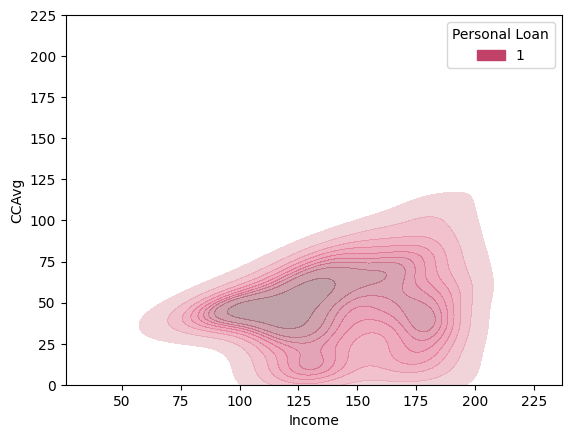

In [16]:
df_kdeplot = df[df['Personal Loan'] == 1].copy()
df_kdeplot['CCAvg'] = df_kdeplot['CCAvg'] * 12
ax = sns.kdeplot(
    data=df_kdeplot,
    x='Income',
    y='CCAvg',
    hue='Personal Loan',
    shade = True,
    fill=True,
    linewidth=2,
    alpha=.5,
    palette='flare',
    common_norm=False,
)
ax.set_ylim(0,225)
plt.show()


- The KDE plot shows that customers who accepted the personal loan tend to have **higher incomes** (concentrated around $100K–$180K) and **moderate-to-high annual credit card spending** ($20K–$100K).
- The density is highest in the income range of $100K–$150K with annual CC spending of $30K–$80K, indicating this is the "sweet spot" for loan acceptance.

### 4.7 Geographic Distribution of Loan Acceptors

Using the `uszipcode` library, we geocode the ZIP codes of customers who accepted the loan and plot their locations on an interactive map.

In [ ]:
import plotly.express as px
import uszipcode


df_locs = df[df['Personal Loan']==1]
zip_codes = df_locs['ZIP Code'].astype(str).values

search = uszipcode.SearchEngine()

city = []
lat = []
lon = []
for zipcode in df_locs['ZIP Code']:   
    req = search.by_zipcode(zipcode)
    city.append(req.city)
    lat.append(req.lat)
    lon.append(req.lng)


df_locs = pd.DataFrame({
    'City': city,
    'Lat' : lat,
    'Lon': lon
})

# Number of geocoded loan acceptors (rows, columns)
print(df_locs.shape)
# Check for missing values after geocoding (some ZIP codes may not resolve to valid coordinates)
print(f'Number of missing cities: {df_locs.isna().sum()}')

fig = px.scatter_mapbox(df_locs, lat="Lat", lon="Lon", hover_name="City", zoom=5)


fig.update_layout(
    mapbox_style="white-bg", 
    mapbox_layers=[
        {
            "below": 'traces', 
            "sourcetype": "raster",
            "sourceattribution": "Google Maps",
            "source": [
                "https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}"
            ]
        }
    ],
    margin={"r":0, "t":0, "l":0, "b":0} 
)


fig.update_traces(marker=dict(size=5, color='red'))

fig.show()

(480, 3)
City     3
Lat     65
Lon     65
dtype: int64



- The map reveals that customers who accepted the personal loan are predominantly located in **California** (Los Angeles and San Francisco metro areas).
- This geographic concentration might indicate regional economic factors or bank branch presence influencing loan acceptance rates.

## 5. Train-Test Split

We split the data into **80% training** and **20% test** sets, using stratified sampling to maintain the class distribution. The `ZIP Code` column is dropped as it is not a meaningful predictor.

In [18]:
X = df.drop(['Personal Loan','ZIP Code','Experience'],axis=1)
Y = df['Personal Loan'].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

## 6. Model 1: Logistic Regression

### 6.1 Solver Selection via Cross-Validation

We test multiple solvers (`lbfgs`, `saga`, `liblinear`, `sag`, `newton-cg`) using 5-fold cross-validation with F1 score to find the best-performing solver for our Logistic Regression model. A `MinMaxScaler` is applied within a pipeline to prevent data leakage.

In [ ]:
solver = ['lbfgs','saga','liblinear','sag','newton-cg']
f1_score_lst = [] 
for sol in solver:

    pipeline = Pipeline([
        ('scaler',MinMaxScaler()),
        ('logreg',LogisticRegression(solver=sol, max_iter=500,random_state=42))
    ])

    kfold = KFold(n_splits=5,shuffle=True,random_state=42)
    f1_score = cross_val_score (pipeline,X_train,y_train,cv=kfold,scoring='f1')
    f1_score_lst.append(f1_score.mean())

df_solver = pd.DataFrame({
    'solver' : solver,
    'f1_score' : f1_score_lst
})

df_solver = df_solver.sort_values('f1_score',ascending=False)
print(df_solver)
best_solver = df_solver.iloc[0,0]
print(f'The best solver is: {best_solver}')


      solver  f1_score
1       saga  0.676420
3        sag  0.676420
4  newton-cg  0.676420
0      lbfgs  0.675860
2  liblinear  0.662257
The best solver is: saga


### 6.2 Model Training & Evaluation

Train the Logistic Regression using the best solver and evaluate on the test set with classification report, confusion matrix, and ROC curve.

In [20]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(solver=best_solver, max_iter=500, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
print(f"Classes: {logreg.classes_}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")
print(f"Coefficients:\n{logreg.coef_}")
print(f"Predicted Probabilities:\n{logreg.predict_proba(X_test_scaled)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"F1 Score: {metrics.f1_score(y_test, y_pred)}")

Classes: [0 1]
Confusion Matrix:
[[896   8]
 [ 39  57]]
Coefficients:
[[ 0.26583663  8.71288975  1.58173917  1.61755171  2.71197448  0.30098078
  -0.72584126  3.28505439 -0.57102747 -0.87538708]]
Predicted Probabilities:
[[0.99355278 0.00644722]
 [0.21710734 0.78289266]
 [0.97550933 0.02449067]
 ...
 [0.99733788 0.00266212]
 [0.99453211 0.00546789]
 [0.98935272 0.01064728]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       904
           1       0.88      0.59      0.71        96

    accuracy                           0.95      1000
   macro avg       0.92      0.79      0.84      1000
weighted avg       0.95      0.95      0.95      1000

F1 Score: 0.7080745341614907


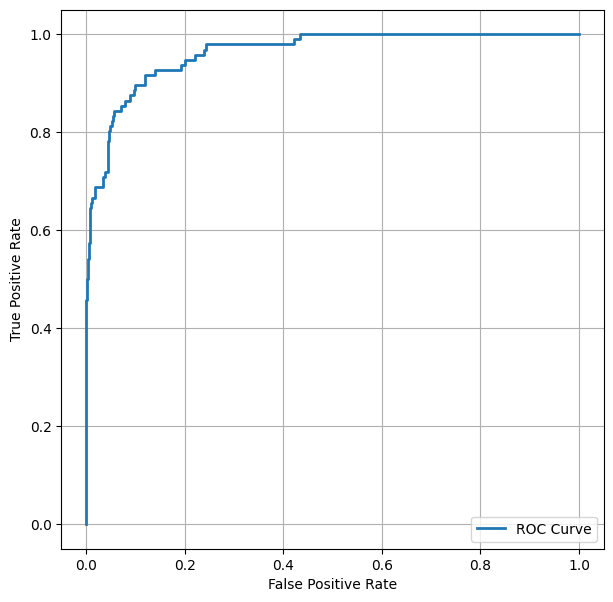

In [21]:
y_pred_proba = logreg.predict_proba(X_test_scaled)[:,1]
fpr, tpr , threshhold =  roc_curve(y_test,y_pred_proba)

plt.figure(figsize=[7,7])
plt.plot(fpr,tpr,label="ROC Curve",linewidth=2)
plt.legend(loc=4)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.grid()
plt.show()


- Logistic Regression achieves a reasonable performance but may struggle with the minority class (loan acceptance) due to the linear decision boundary.
- The **ROC curve** shows the trade-off between True Positive Rate and False Positive Rate. A curve closer to the top-left corner indicates better discrimination between classes.

## 7. Model 2: K-Nearest Neighbors (KNN)

### 7.1 Hyperparameter Tuning (F1 Score)

We use `GridSearchCV` to find the optimal `n_neighbors`, distance `metric`, and `weights` for KNN, optimizing for F1 score.

In [22]:

pipe = Pipeline([
    ('scaler',MinMaxScaler()),
    ('knn',KNeighborsClassifier())
])

param = { "knn__n_neighbors": range(1,30), 
          "knn__metric" : ['euclidean','manhattan'],
          "knn__weights" : ['uniform','distance']
          }


grid_knn = GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring='f1',
    n_jobs= -1
    )

grid_knn.fit(X_train,y_train.ravel())

print(f"Best cross-validation F1 score: {grid_knn.best_score_}")
print(f"Best parameters: {grid_knn.best_params_}")


Best cross-validation F1 score: 0.7699252092087254
Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}


### 7.2 F1 Score vs. Number of Neighbors

Plotting training and test F1 scores across different values of `n_neighbors` (1–29) helps visualize the bias-variance trade-off.

    n_neighbors  training_f1_score  test_f1_score
0             1           1.000000       0.802198
1             2           0.832827       0.697368
2             3           0.882857       0.771084
3             4           0.789969       0.693333
4             5           0.824773       0.721519
5             6           0.769475       0.653061
6             7           0.799383       0.688742
7             8           0.741463       0.638889
8             9           0.758294       0.648276
9            10           0.697674       0.624113
10           11           0.721044       0.643357
11           12           0.679117       0.624113
12           13           0.685524       0.643357
13           14           0.631763       0.594203
14           15           0.648370       0.624113


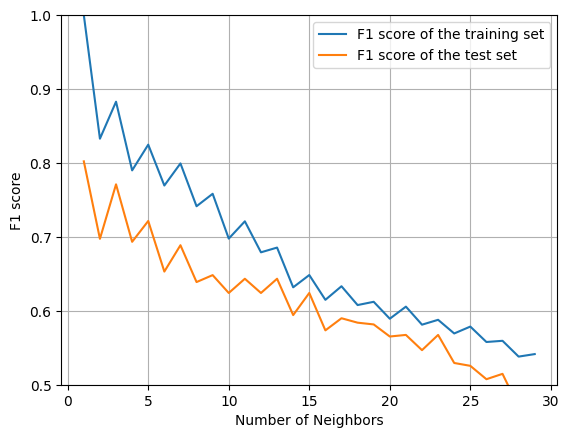

In [23]:
training_f1_score = []
test_f1_score = []
n_neighbors_lst = []
n_neighbors_range = range(1,30)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for n in n_neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=n, metric= 'euclidean')
    knn.fit(X_train_scaled,y_train)
    y_pred = knn.predict(X_test_scaled)
    y_pred_train = knn.predict(X_train_scaled)
    n_neighbors_lst.append(n)
    training_f1_score.append(metrics.f1_score(y_train,y_pred_train))
    test_f1_score.append(metrics.f1_score(y_test,y_pred))

df_neighbours = pd.DataFrame({
    'n_neighbors' : n_neighbors_lst,
    'training_f1_score' : training_f1_score,
    'test_f1_score' : test_f1_score
})

print(df_neighbours.head(15))

plt.plot(n_neighbors_range, training_f1_score, label="F1 score of the training set")
plt.plot(n_neighbors_range, test_f1_score, label="F1 score of the test set")
plt.xlabel("Number of Neighbors")
plt.ylabel("F1 score")
plt.ylim(.50,1)
plt.grid(True)
plt.legend()
plt.show()


- At **k=1**, the training F1 is perfect (1.0) but the test F1 is lower, indicating **overfitting**.
- As `k` increases, the training F1 decreases while the test F1 initially improves and then plateaus or slightly drops.
- The best trade-off between training and test performance typically occurs around **k=3–7**, where the gap between training and test F1 is small.

### 7.3 Hyperparameter Tuning (Accuracy)

We repeat the GridSearch using **accuracy** as the scoring metric for comparison.

In [24]:

pipe = Pipeline([
    ('scaler',MinMaxScaler()),
    ('knn',KNeighborsClassifier())
])

params = { "knn__n_neighbors": range(1,30), 
          "knn__metric" : ['euclidean','manhattan'],
          "knn__weights" : ['uniform','distance']
          }


grid_knn = GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs= -1
    )

grid_knn.fit(X_train,y_train.ravel())

print(grid_knn.best_score_)
print(grid_knn.best_params_)


0.9629909261576971
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}


### 7.4 Accuracy vs. Number of Neighbors

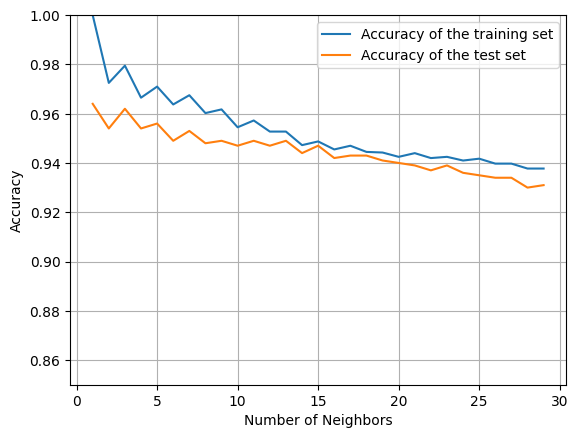

In [25]:
training_f1_score = []
test_f1_score = []
n_neighbors_range = range(1,30)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for n in n_neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=n, metric= 'euclidean')
    knn.fit(X_train_scaled,y_train)
    y_pred = knn.predict(X_test_scaled)
    y_pred_train = knn.predict(X_train_scaled)
    training_f1_score.append(metrics.accuracy_score(y_train,y_pred_train))
    test_f1_score.append(metrics.accuracy_score(y_test,y_pred))

plt.plot(n_neighbors_range, training_f1_score, label="Accuracy of the training set")
plt.plot(n_neighbors_range, test_f1_score, label="Accuracy of the test set")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.ylim(.85,1)
plt.grid(True)
plt.legend()
plt.show()

**Understanding:**
- Accuracy is consistently high (>90%) across all `k` values, which is misleading due to the **class imbalance** — a naive classifier predicting "no loan" for everyone would still achieve ~90% accuracy.
- The F1 score (from Section 7.2) is a more reliable metric for this imbalanced dataset, as it balances precision and recall for the minority class.

## 8. Model 3: Complement Naive Bayes

**Complement Naive Bayes** is particularly suited for **imbalanced datasets**, as it uses the complement of each class to compute weights. We use `GridSearchCV` to tune the `alpha` (smoothing) and `norm` parameters.

In [26]:
X = df.drop(['Personal Loan','ZIP Code','Experience'],axis=1)
Y = df['Personal Loan'].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

In [27]:

pipeline = Pipeline([
    ('scaler',MinMaxScaler()),
    ('cnb', ComplementNB(fit_prior=True))
])

kfold = KFold(n_splits=5, random_state=42, shuffle=True)

params = {
    'cnb__alpha' : [.01, .1, .5, 1, 10],
    'cnb__norm' : [True,False]
}

grid_cnb = GridSearchCV(
    param_grid= params,
    cv= kfold,
    estimator = pipeline,
    scoring='f1'
)

grid_cnb.fit(X_train,y_train)



GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('cnb', ComplementNB())]),
             param_grid={'cnb__alpha': [0.01, 0.1, 0.5, 1, 10],
                         'cnb__norm': [True, False]},
             scoring='f1')

In [28]:
print(f"Best parameters for Complement Naive Bayes: {grid_cnb.best_params_}")
print(f"Best cross-validation F1 score: {grid_cnb.best_score_}")

Best parameters for Complement Naive Bayes: {'cnb__alpha': 0.01, 'cnb__norm': False}
Best cross-validation F1 score: 0.40631334517346296



- The F1 score for Complement Naive Bayes is **notably low** compared to Logistic Regression and KNN. This is primarily because CNB relies on the **strong assumption of feature independence**, which is violated in our dataset — for example, `Income` and `CCAvg` are moderately correlated (~0.65), and `Age` and `Experience` are nearly perfectly correlated (~0.99). These dependencies degrade the model's ability to correctly identify loan acceptors.
- Additionally, CNB is designed for **count/frequency data** (e.g., text classification), so applying it to continuous numerical features — even after scaling — is not ideal and further limits its performance.


## 9. Conclusion

1. **Income**, **CCAvg**, **Education**, and **CD Account** are the strongest predictors of personal loan acceptance.
2. The dataset is **highly imbalanced** (~90% negative class), making **F1 score** a more appropriate metric than accuracy.
3. **KNN** with proper hyperparameter tuning tends to achieve the highest F1 score among the three models tested.
4. Feature scaling (MinMaxScaler) is critical for distance-based models (KNN) and gradient-based solvers (Logistic Regression).